In [1]:
from pathlib import Path

nnunet_dir = Path("/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet")


## Method 1 : train nnunet from scratch on full body scans

In [2]:
# train model 
import json
dataset_name = "Dataset001_Vertebrae"

imgs_dir     = nnunet_dir / "nnUNet_raw" / dataset_name / "imagesTr"
roi_dir      = nnunet_dir / "nnUNet_raw" / dataset_name / "labelsTr"
#vertebrae_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "l1_segmentations"
"""
export nnUNet_raw="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw"
export nnUNet_preprocessed="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_preprocessed"
export nnUNet_results="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_results"

nnUNetv2_plan_and_preprocess -np 16 -d 1 --verify_dataset_integrity -c 3d_fullres -pl nnUNetPlannerResEncM 
nnUNetv2_train 1 3d_fullres 1 -p nnUNetResEncMUNetPlans 
"""


'\nexport nnUNet_raw="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw"\nexport nnUNet_preprocessed="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_preprocessed"\nexport nnUNet_results="/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_results"\n\nnnUNetv2_plan_and_preprocess -np 16 -d 1 --verify_dataset_integrity -c 3d_fullres -pl nnUNetPlannerResEncM \nnnUNetv2_train 1 3d_fullres 1 -p nnUNetResEncMUNetPlans \n'

In [4]:
# eval model on val set
fold_id = 1
split_file_path = nnunet_dir / "nnUNet_preprocessed" / dataset_name / "splits_final.json"
splits = json.load(open(split_file_path))
val_cases = splits[fold_id]["val"]

# copy images and rois to new folder for evaluation
eval_imgs_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "imagesTs"
eval_rois_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "labelsTs"
eval_imgs_dir.mkdir(exist_ok=True)
eval_rois_dir.mkdir(exist_ok=True)
for case in val_cases:
    img_path = imgs_dir / f"{case}_0000.nii.gz"
    roi_path = roi_dir / f"{case}.nii.gz"
    img_eval_path = eval_imgs_dir / f"{case}_0000.nii.gz"
    roi_eval_path = eval_rois_dir / f"{case}.nii.gz"
    img_eval_path.symlink_to(img_path)
    roi_eval_path.symlink_to(roi_path)

FileExistsError: [Errno 17] File exists: '/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset001_Vertebrae/imagesTr/24168972_20220508154531_0000.nii.gz' -> '/nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset001_Vertebrae/imagesTs/24168972_20220508154531_0000.nii.gz'

nnUNetv2_predict -i /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset001_Vertebrae/imagesTs \
    -o /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset001_Vertebrae/predsTs \
    -d 1 \
    -c 3d_fullres \
    -f 1 \
    -tr nnUNetTrainer \
    -p nnUNetResEncUNetMPlans \
    -chk checkpoint_best.pth

# ~2 mins/case

In [6]:
# export to nora 
import os

project_name = "zanderch___HU_Messung"
preds_dir = nnunet_dir / "nnUNet_raw" / dataset_name / "predsTs"
preds_regex = r"(?<patients_id>\d+)_(?<studies_id>\d+)\.nii\.gz"

print("Importing preds...")
print(f"nora -p {project_name} --importfiles {preds_dir} '{preds_regex}'")


Importing preds...
nora -p zanderch___HU_Messung --importfiles /nfs/data/nii/data1/Analysis/zanderch___HU_Messung/ANALYSIS_seg/nnunet/nnUNet_raw/Dataset001_Vertebrae/predsTs '(?<patients_id>\d+)_(?<studies_id>\d+)\.nii\.gz'


In [ ]:
# compute metrics
import sys
import nibabel as nib
import numpy as np
sys.path.insert(0, "/home/dpxuser/dev/whole_body_benchmark")
from src.compute_metrics import dice 
dices = []
for case in val_cases:
    img_path = imgs_dir / f"{case}_0000.nii.gz"
    pred_path = preds_dir / f"{case}.nii.gz"
    gt_path = roi_dir / f"{case}.nii.gz"
    print(f"Computing metrics for case {case}...")
    pred_nii = nib.load(pred_path)
    gt_nii = nib.load(gt_path)
    gt   = np.asarray(gt_nii.dataobj, dtype=np.int32)
    pred = np.asarray(pred_nii.dataobj, dtype=np.int32)
    dice_score = dice(pred, gt)
    print(f"Dice score for case {case}: {dice_score}")
    dices.append(dice_score)
    

    


Computing metrics for case 24168972_20220508154531...
Computing metrics for case 26245249_20230417165056...
Computing metrics for case 27441734_20240726125039...
Computing metrics for case 33839529_20240907143657...
Computing metrics for case 43503901_20220812204636...
Computing metrics for case 43797212_20230110192527...
Computing metrics for case 44316900_20230905181914...


In [11]:
dices

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.32300038270187525),
 np.float64(0.0)]

In [9]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label as nd_label
import sys
sys.path.insert(0, "/home/dpxuser/dev/whole_body_benchmark")
from src.compute_metrics import dice


def eval_case(img_path, pred_path, gt_path, label=1):
    img_nii  = nib.load(img_path)
    pred_nii = nib.load(pred_path)
    gt_nii   = nib.load(gt_path)

    img  = np.asarray(img_nii.dataobj,  dtype=np.float32)
    pred = np.asarray(pred_nii.dataobj, dtype=np.int32)
    gt   = np.asarray(gt_nii.dataobj,   dtype=np.int32)

    spacing = np.array(gt_nii.header.get_zooms()[:3])

    pred_mask = pred == label
    gt_mask   = gt   == label

    # Dice
    dice_score = dice(gt_mask, pred_mask)

    # Dice on largest connected component of pred
    labeled, n = nd_label(pred_mask)
    if n > 0:
        sizes = [(labeled == i).sum() for i in range(1, n + 1)]
        largest = labeled == (np.argmax(sizes) + 1)
        dice_lcc = dice(gt_mask, largest)
    else:
        dice_lcc = float("nan")

    # Center of mass distance in mm
    def center_of_mass(mask):
        coords = np.array(np.where(mask), dtype=float)
        return coords.mean(axis=1) if coords.size > 0 else None

    gt_center   = center_of_mass(gt_mask)
    pred_center = center_of_mass(pred_mask)

    if gt_center is not None and pred_center is not None:
        center_dist_mm = np.linalg.norm((gt_center - pred_center) * spacing)
    else:
        center_dist_mm = float("nan")

    print(f"Dice:              {dice_score:.4f}")
    print(f"Dice (largest CC): {dice_lcc:.4f}")
    print(f"Center distance:   {center_dist_mm:.2f} mm")

    # Slices centered on GT centroid
    if gt_center is not None:
        cx, cy, cz = (int(round(c)) for c in gt_center)
    else:
        cx, cy, cz = (s // 2 for s in img.shape)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    slices = [
        ("Axial (z)",    img[:, :, cz],  gt_mask[:, :, cz],  pred_mask[:, :, cz]),
        ("Coronal (y)",  img[:, cy, :],  gt_mask[:, cy, :],  pred_mask[:, cy, :]),
        ("Sagittal (x)", img[cx, :, :],  gt_mask[cx, :, :],  pred_mask[cx, :, :]),
    ]
    for ax, (title, img_sl, gt_sl, pred_sl) in zip(axes, slices):
        vmin, vmax = np.percentile(img_sl, [1, 99])
        ax.imshow(img_sl.T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        for sl, color in [(gt_sl, [0, 1, 0, 0.4]), (pred_sl, [1, 0, 0, 0.4])]:
            overlay = np.zeros((*sl.shape, 4))
            overlay[sl] = color
            ax.imshow(overlay.transpose(1, 0, 2), origin="lower")
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle(f"GT=green  Pred=red  |  Dice={dice_score:.3f}  LCC={dice_lcc:.3f}  Δcenter={center_dist_mm:.1f}mm")
    plt.tight_layout()
    plt.show()

    return {"dice": dice_score, "dice_lcc": dice_lcc, "center_dist_mm": center_dist_mm}


Dice:              0.0000
Dice (largest CC): 0.0000
Center distance:   70.13 mm


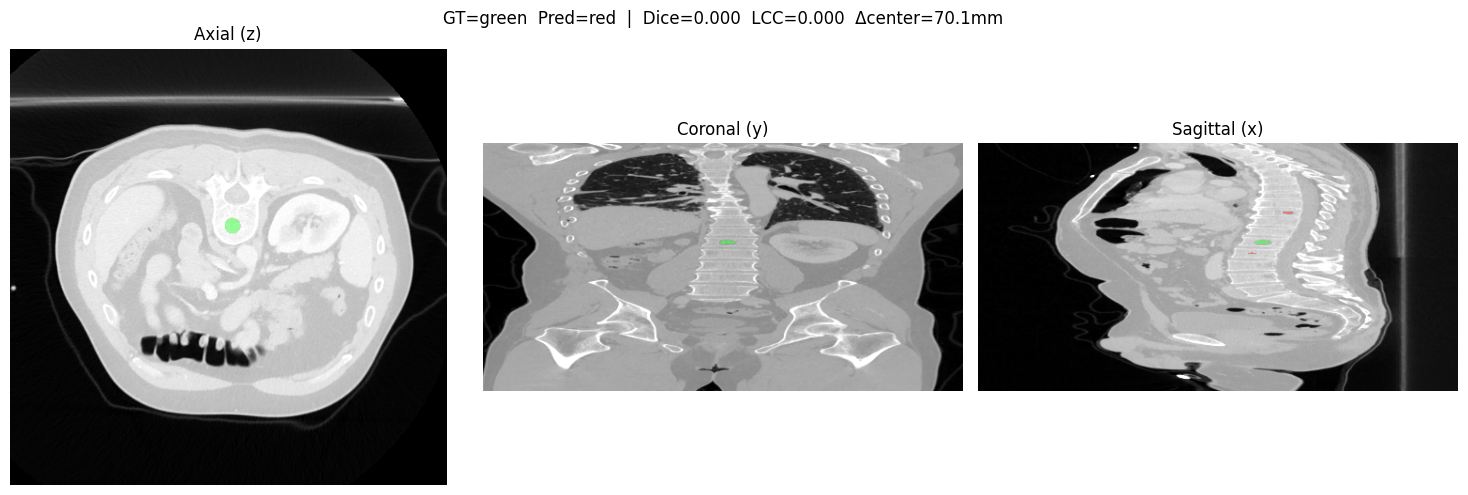

Dice:              0.0000
Dice (largest CC): 0.0000
Center distance:   19.14 mm


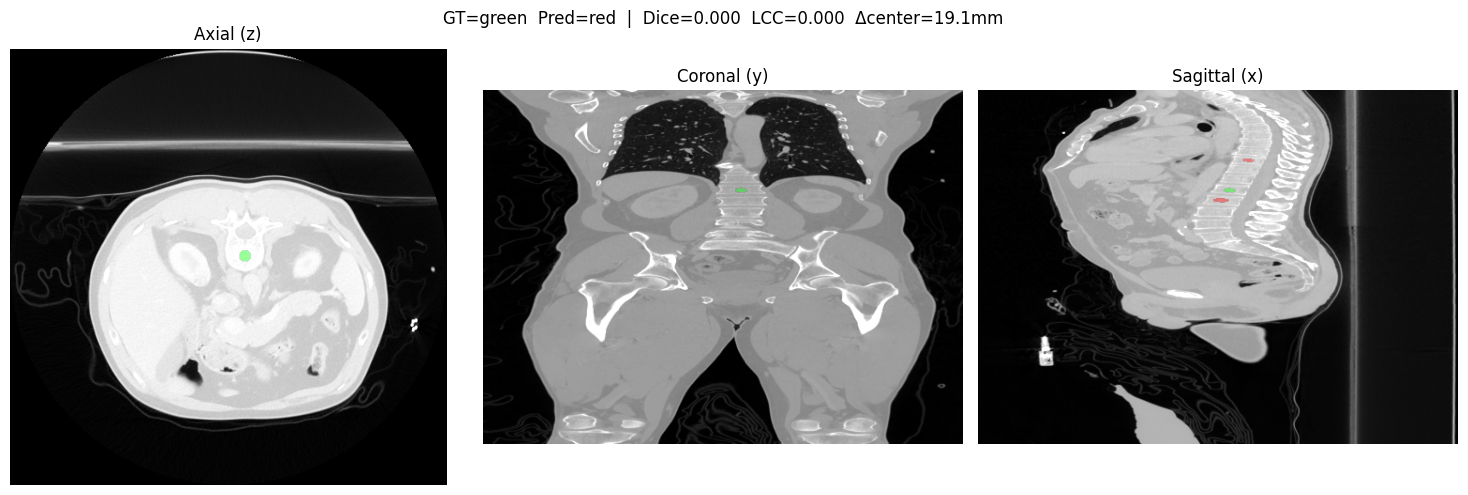

Dice:              0.0000
Dice (largest CC): 0.0000
Center distance:   73.91 mm


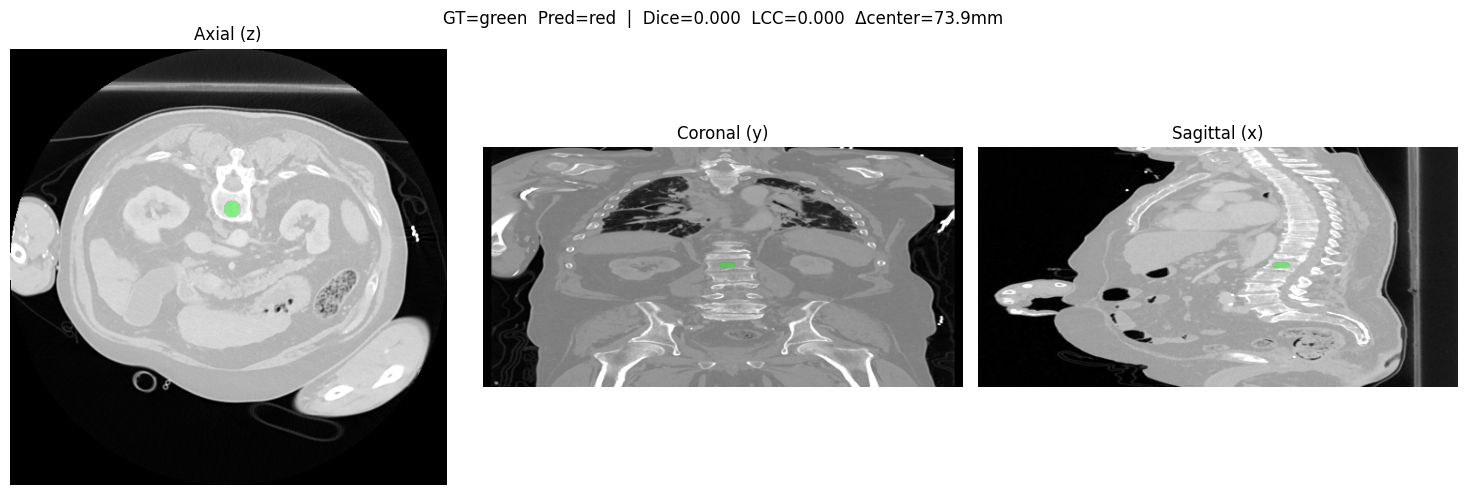

Dice:              0.0000
Dice (largest CC): 0.0000
Center distance:   18.24 mm


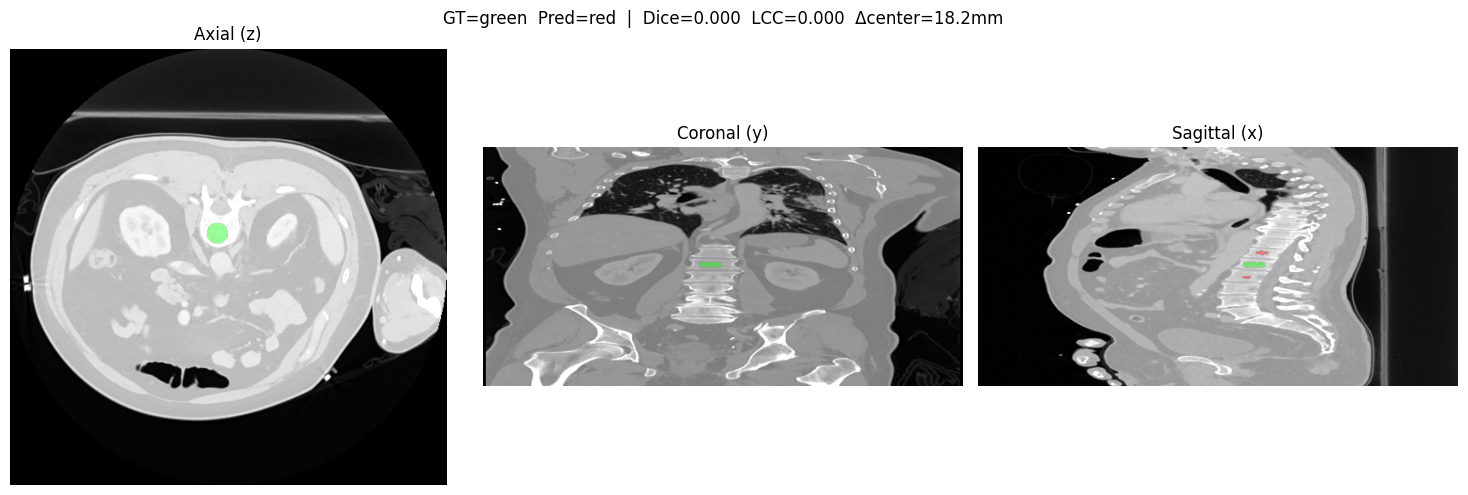

Dice:              0.0000
Dice (largest CC): 0.0000
Center distance:   107.39 mm


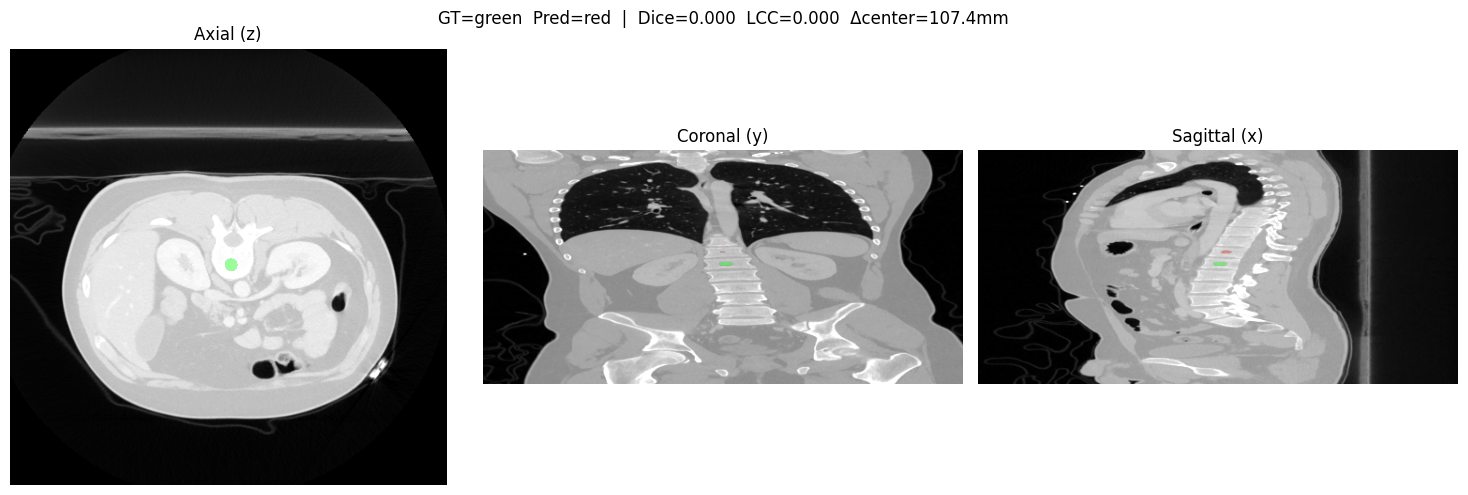

Dice:              0.3230
Dice (largest CC): 0.0000
Center distance:   125.53 mm


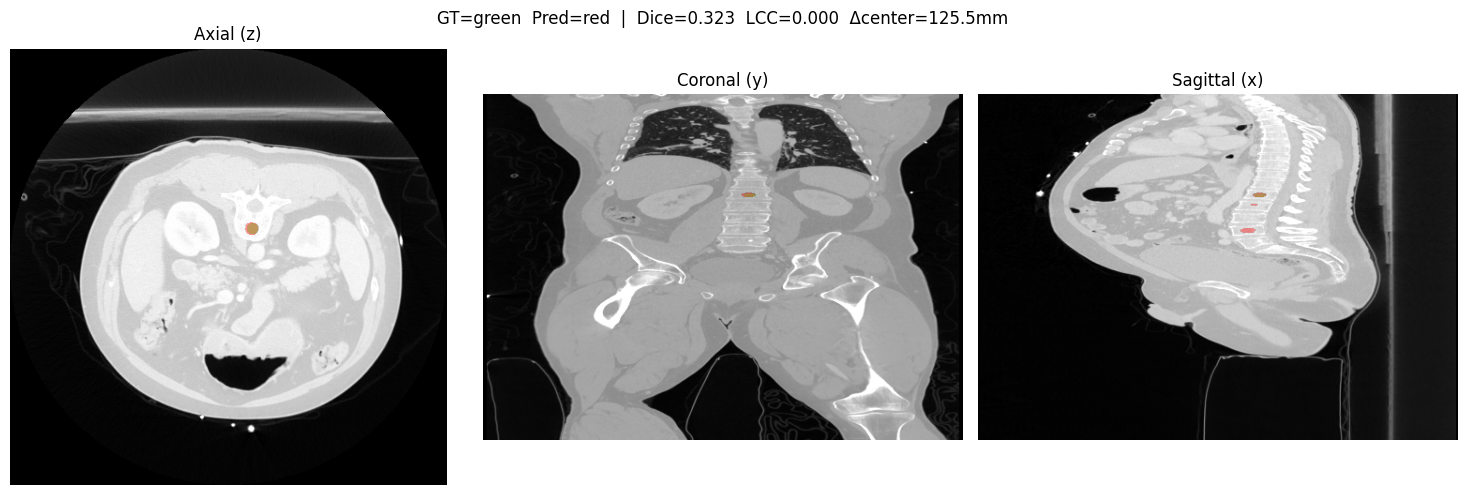

Dice:              0.0000
Dice (largest CC): 0.0000
Center distance:   18.41 mm


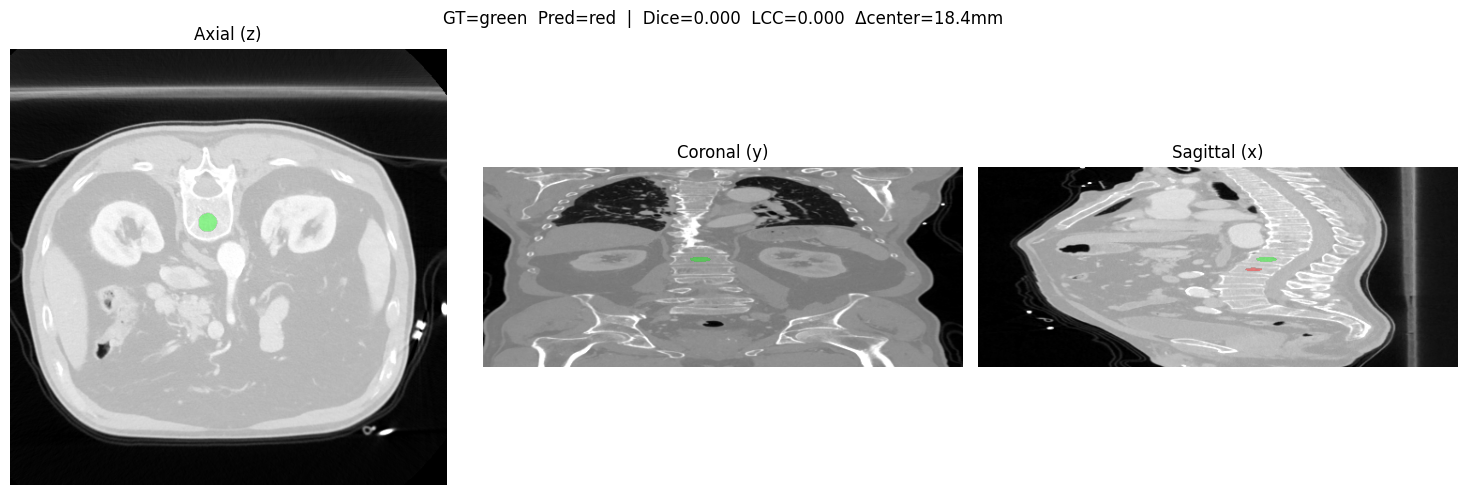

In [10]:
for case in val_cases:
    img_path = imgs_dir / f"{case}_0000.nii.gz"
    pred_path = preds_dir / f"{case}.nii.gz"
    gt_path = roi_dir / f"{case}.nii.gz"
    eval_case(img_path, pred_path, gt_path, label=1)